<a href="https://colab.research.google.com/github/Malope-cmd/Porfolio-Optimization/blob/main/Portfolio_Notebook_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Portfolio Optimization
* Build a stocks portfolio over 1.5 months
* This portfolio starts on 31 May 2026 and forecast to around 15 July 2026.
* This project uses Classic Monte Carlo Simulation and focuses on the 50h percentile path and mean path.
* The four stocks are Apple Inc, Microsoft Corporation, JP Morgan & Chase co and Exxon Mobil Corporation.
* All the data is imported from Yahoo Finance

## Import all data
* Stocks included are Apple, Microsoft, JP Morgan and Exxon.

In [ ]:
import yfinance as yf

In [ ]:
# Getting stocks from Yahoo finance
stock_i= "AAPL"   # Apple Inc
stock_ii = "MSFT"   # Microsoft Corporation (Technology)
stock_iii = "JPM"     # JPMorgan Chase & Co. (Financial Services)
stock_iv = "XOM"   # Exxon Mobil Corporation (Energy)

In [ ]:
"""
# Other popular stocks to consider:
stock_v = "GOOGL"  # Alphabet Inc. (Technology)
stock_vi = "AMZN"   # Amazon.com, Inc. (E-commerce/Cloud)
stock_vii = "TSLA"  # Tesla, Inc. (Automotive/Energy)
stock_viii = "BRK.A" # Berkshire Hathaway Inc. (Conglomerate)
stock_ix = "V"     # Visa Inc. (Financial Services)
"""

'\n# Other popular stocks to consider:\nstock_v = "GOOGL"  # Alphabet Inc. (Technology)\nstock_vi = "AMZN"   # Amazon.com, Inc. (E-commerce/Cloud)\nstock_vii = "TSLA"  # Tesla, Inc. (Automotive/Energy)\nstock_viii = "BRK.A" # Berkshire Hathaway Inc. (Conglomerate)\nstock_ix = "V"     # Visa Inc. (Financial Services)\n'

In [ ]:
stock_dfi = yf.download(stock_i,  start="2026-01-01", end="2026-05-31")
stock_dfii = yf.download(stock_ii,start='2026-01-01', end='2026-05-31')
stock_dfiii = yf.download(stock_iii,  start="2026-01-01", end="2026-05-31")
stock_dfiv = yf.download(stock_iv,start='2026-01-01', end='2026-05-31')

/tmp/ipykernel_2361/89336671.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_dfi = yf.download(stock_i,  start="2026-01-01", end="2026-05-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2361/89336671.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_dfii = yf.download(stock_ii,start='2026-01-01', end='2026-05-31')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2361/89336671.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_dfiii = yf.download(stock_iii,  start="2026-01-01", end="2026-05-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2361/89336671.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_dfiv = yf.download(stock_iv,start='2026-01-01', end='2026-05-31')
[*********************100%***************

View how each dataframe looks

In [ ]:
stock_dfi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2026-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   102 non-null    float64
 1   (High, AAPL)    102 non-null    float64
 2   (Low, AAPL)     102 non-null    float64
 3   (Open, AAPL)    102 non-null    float64
 4   (Volume, AAPL)  102 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.8 KB


In [ ]:
stock_dfii.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2026-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   102 non-null    float64
 1   (High, MSFT)    102 non-null    float64
 2   (Low, MSFT)     102 non-null    float64
 3   (Open, MSFT)    102 non-null    float64
 4   (Volume, MSFT)  102 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.8 KB


In [ ]:
stock_dfiii.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2026-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JPM)   102 non-null    float64
 1   (High, JPM)    102 non-null    float64
 2   (Low, JPM)     102 non-null    float64
 3   (Open, JPM)    102 non-null    float64
 4   (Volume, JPM)  102 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.8 KB


In [ ]:
stock_dfiv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2026-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, XOM)   102 non-null    float64
 1   (High, XOM)    102 non-null    float64
 2   (Low, XOM)     102 non-null    float64
 3   (Open, XOM)    102 non-null    float64
 4   (Volume, XOM)  102 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 4.8 KB


Each dataframe has 102 datapoints and covers from January 2026 to May 2026.

In [ ]:
stock_dfi.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-05-22,308.820007,311.399994,305.839996,306.119995,43670200
2026-05-26,308.329987,311.820007,307.670013,309.559998,48000500
2026-05-27,310.850006,313.260010,308.299988,308.329987,50430900
2026-05-28,312.510010,312.799988,309.570007,310.679993,48220400
2026-05-29,312.059998,315.000000,309.529999,311.779999,70026800


In [ ]:
stock_dfii.tail()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-05-22,418.570007,424.399994,416.329987,419.540009,22390300
2026-05-26,416.029999,419.769989,413.019989,416.429993,30398000
2026-05-27,412.670013,415.940002,409.579987,411.010010,28901500
2026-05-28,426.989990,429.489990,412.670013,412.980011,47250500
2026-05-29,450.239990,450.329987,432.359985,432.549988,79654400


In [ ]:
stock_dfiii.tail()

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2026-05-22,306.380005,307.450012,303.839996,304.679993,5973900
2026-05-26,306.739990,309.929993,305.440002,308.489990,7725400
2026-05-27,299.279999,305.899994,295.750000,305.000000,11779200
2026-05-28,296.730011,301.070007,295.750000,297.570007,9757700
2026-05-29,299.309998,299.880005,295.200012,296.399994,13969000


In [ ]:
stock_dfiv.tail()

Price,Close,High,Low,Open,Volume
Ticker,XOM,XOM,XOM,XOM,XOM
Date,,,,,
2026-05-22,154.919998,155.550003,153.169998,154.029999,12948500
2026-05-26,149.809998,154.550003,149.470001,153.500000,13057800
2026-05-27,147.899994,148.690002,145.750000,147.229996,16241100
2026-05-28,146.960007,150.210007,146.869995,149.339996,14012500
2026-05-29,145.259995,146.929993,144.710007,146.190002,27959900


In [ ]:
# Drop all other columns and leave only closing price
stock_dfi = stock_dfi[[('Close', stock_i)]]
stock_dfii = stock_dfii[[('Close', stock_ii)]]
stock_dfiii = stock_dfiii[[('Close', stock_iii)]]
stock_dfiv = stock_dfiv[[('Close', stock_iv)]]

## Data cleaning and Preparation

In [ ]:
import pandas as pnd

In [ ]:
merged_df = pnd.concat([stock_dfi, stock_dfii, stock_dfiii, stock_dfiv], axis=1)

In [ ]:
#merged_df.columns = [col[1] for col in merged_df.columns]

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2026-01-02 to 2026-05-29
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, AAPL)  102 non-null    float64
 1   (Close, MSFT)  102 non-null    float64
 2   (Close, JPM)   102 non-null    float64
 3   (Close, XOM)   102 non-null    float64
dtypes: float64(4)
memory usage: 4.0 KB


In [ ]:
merged_df.head()

Price            Close                                    
Ticker            AAPL        MSFT         JPM         XOM
Date                                                      
2026-01-02  270.507446  470.843201  322.368652  121.016510
2026-01-05  266.764404  470.753601  330.846832  123.690414
2026-01-06  261.873474  476.388519  332.906250  119.437828
2026-01-07  259.847229  481.326508  325.325073  116.911911
2026-01-08  258.559631  475.990265  328.110840  121.273048

## Sample Statistics

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
merged_df.describe()

Price        Close                                    
Ticker        AAPL        MSFT         JPM         XOM
count   102.000000  102.000000  102.000000  102.000000
mean    268.209262  413.711871  303.414902  147.480393
std      16.943947   30.565752   11.323081   11.501362
min     246.242508  355.998932  281.399872  116.911911
25%     257.350037  396.678352  296.166817  145.308182
50%     263.332382  410.411102  303.666260  149.470474
75%     273.840218  423.662384  310.205009  153.783699
max     312.510010  481.326508  332.906250  170.313995

In [ ]:
correlation_matrix = merged_df.corr()

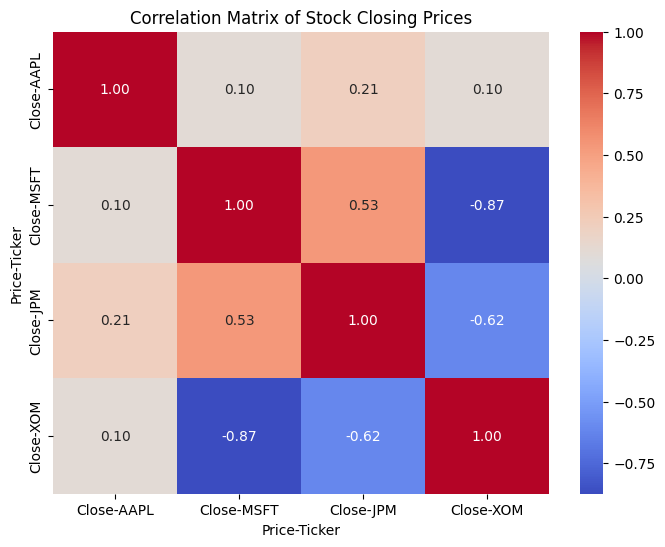

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Closing Prices')
plt.show()

In [ ]:
covariance_matrix = merged_df.cov()

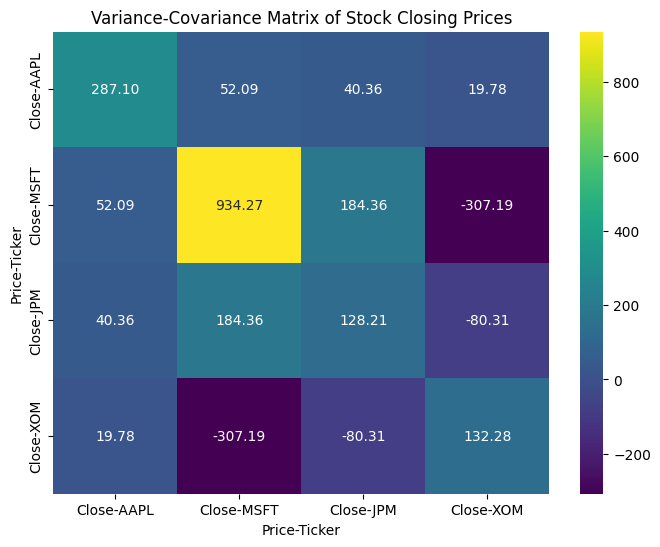

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(covariance_matrix, annot=True, cmap='viridis', fmt=".2f")
plt.title('Variance-Covariance Matrix of Stock Closing Prices')
plt.show()

## Visualizations

*   First charts will be closing prices then followed by daily returns



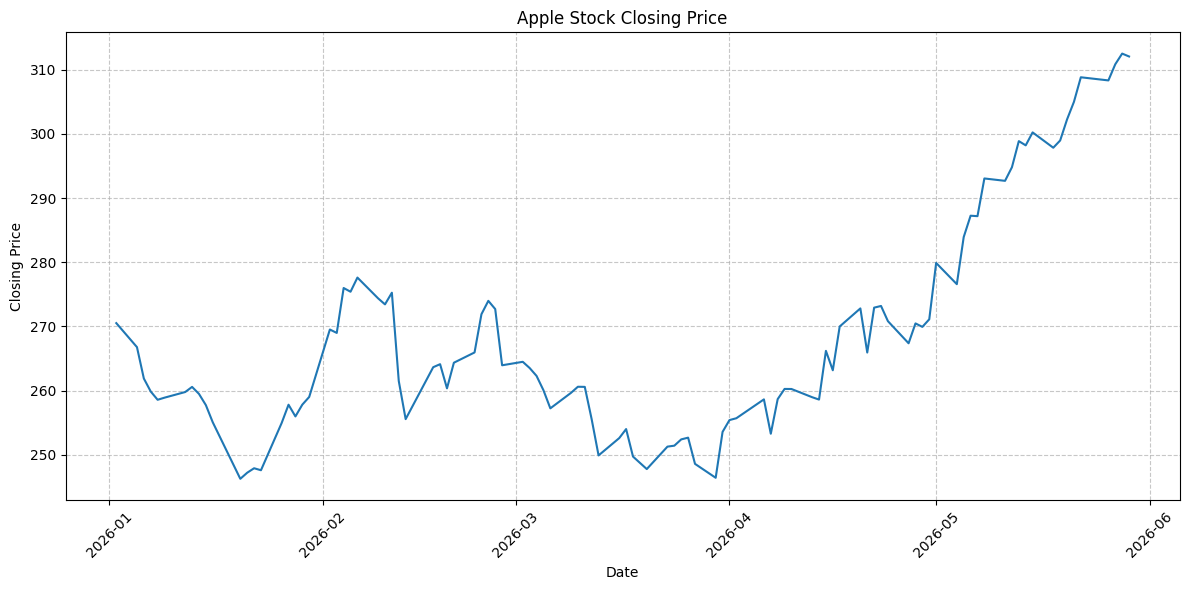

In [ ]:
closing_i = ('Close', stock_i)
plt.figure(figsize=(12, 6))
sns.lineplot(x=stock_dfi.index, y=stock_dfi[closing_i])


plt.title('Apple Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

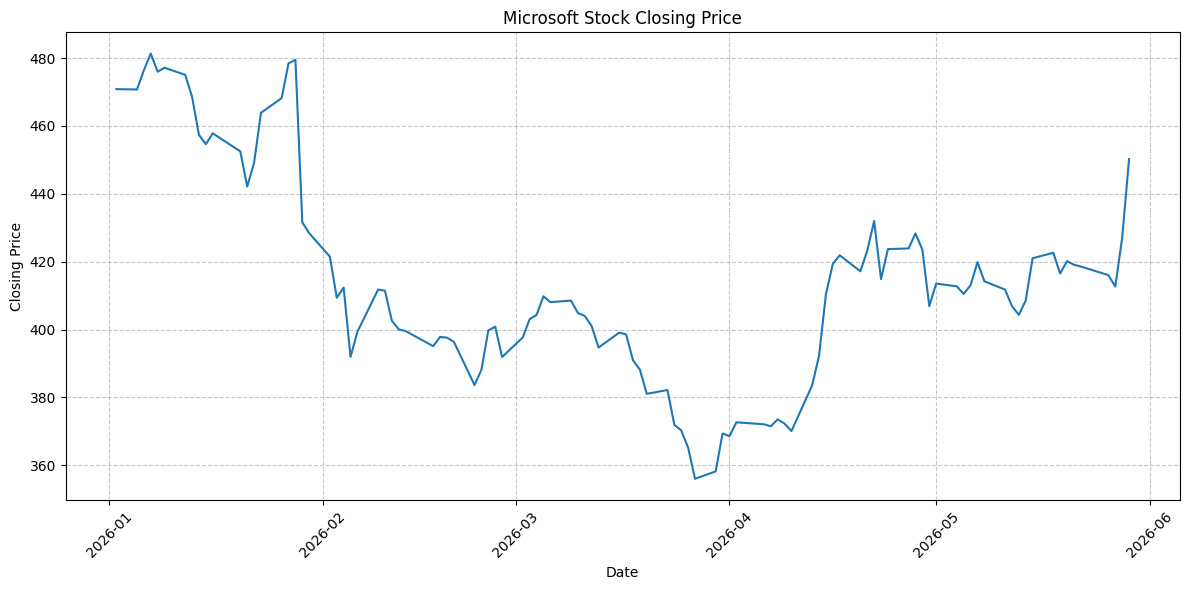

In [ ]:
closing_ii = ('Close', stock_ii)
plt.figure(figsize=(12, 6))
sns.lineplot(x=stock_dfii.index, y=stock_dfii[closing_ii])

# Add titles and labels for clarity
plt.title('Microsoft Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

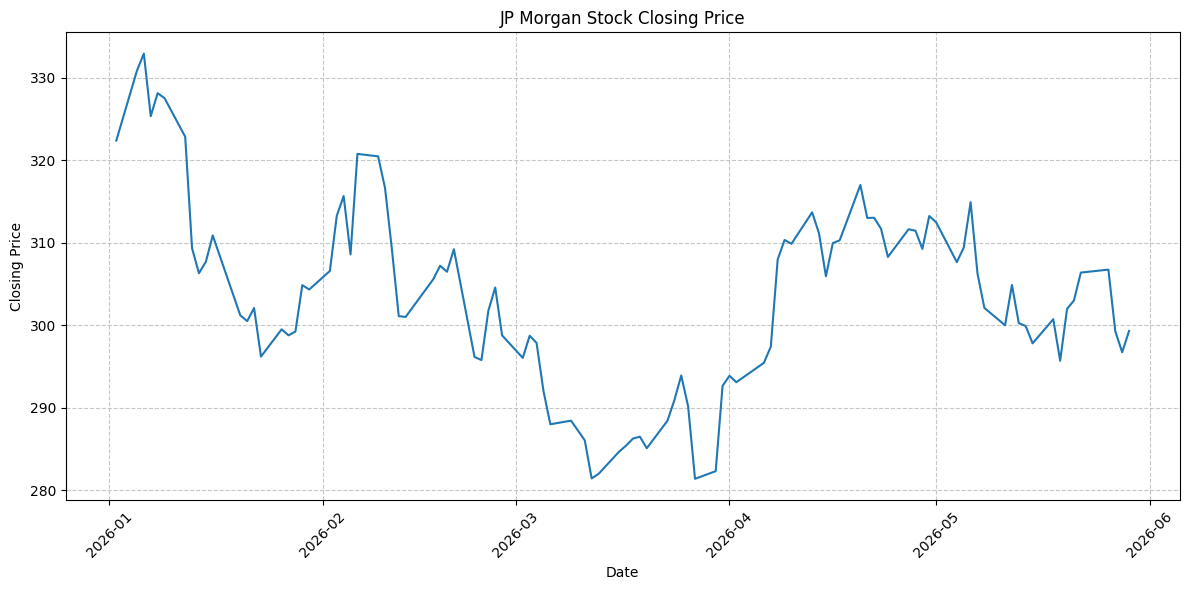

In [ ]:
closing_iii = ('Close', stock_iii)
plt.figure(figsize=(12, 6))
sns.lineplot(x=stock_dfiii.index, y=stock_dfiii[closing_iii])

# Add titles and labels for clarity
plt.title('JP Morgan Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

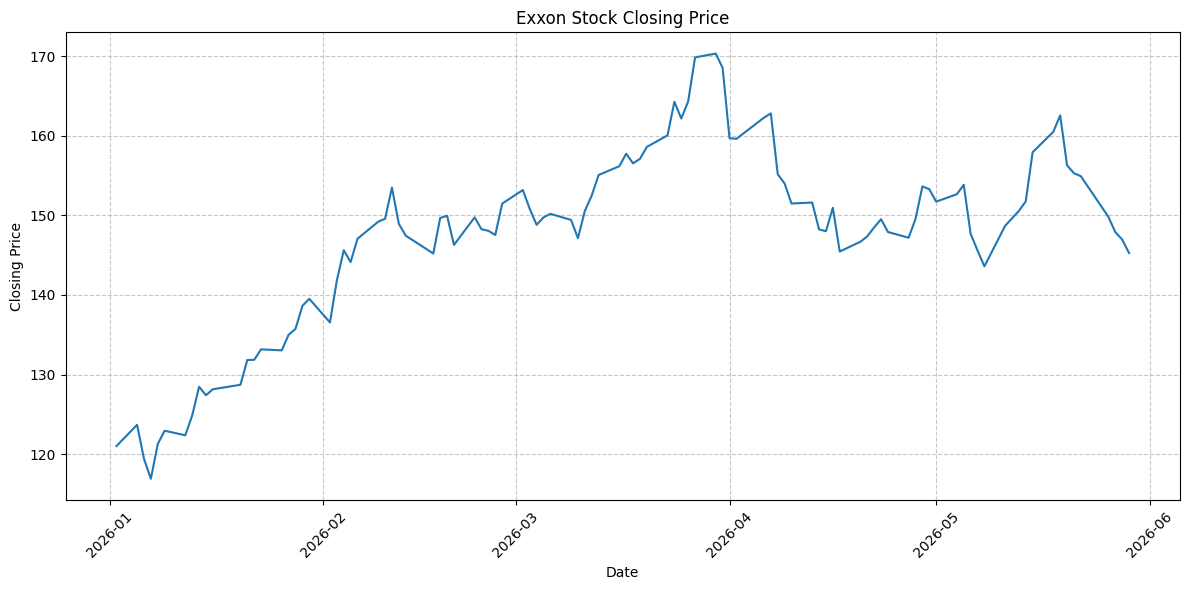

In [ ]:
closing_iv = ('Close', stock_iv)
plt.figure(figsize=(12, 6))
sns.lineplot(x=stock_dfiv.index, y=stock_dfiv[closing_iv])

# Add titles and labels for clarity
plt.title('Exxon Stock Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

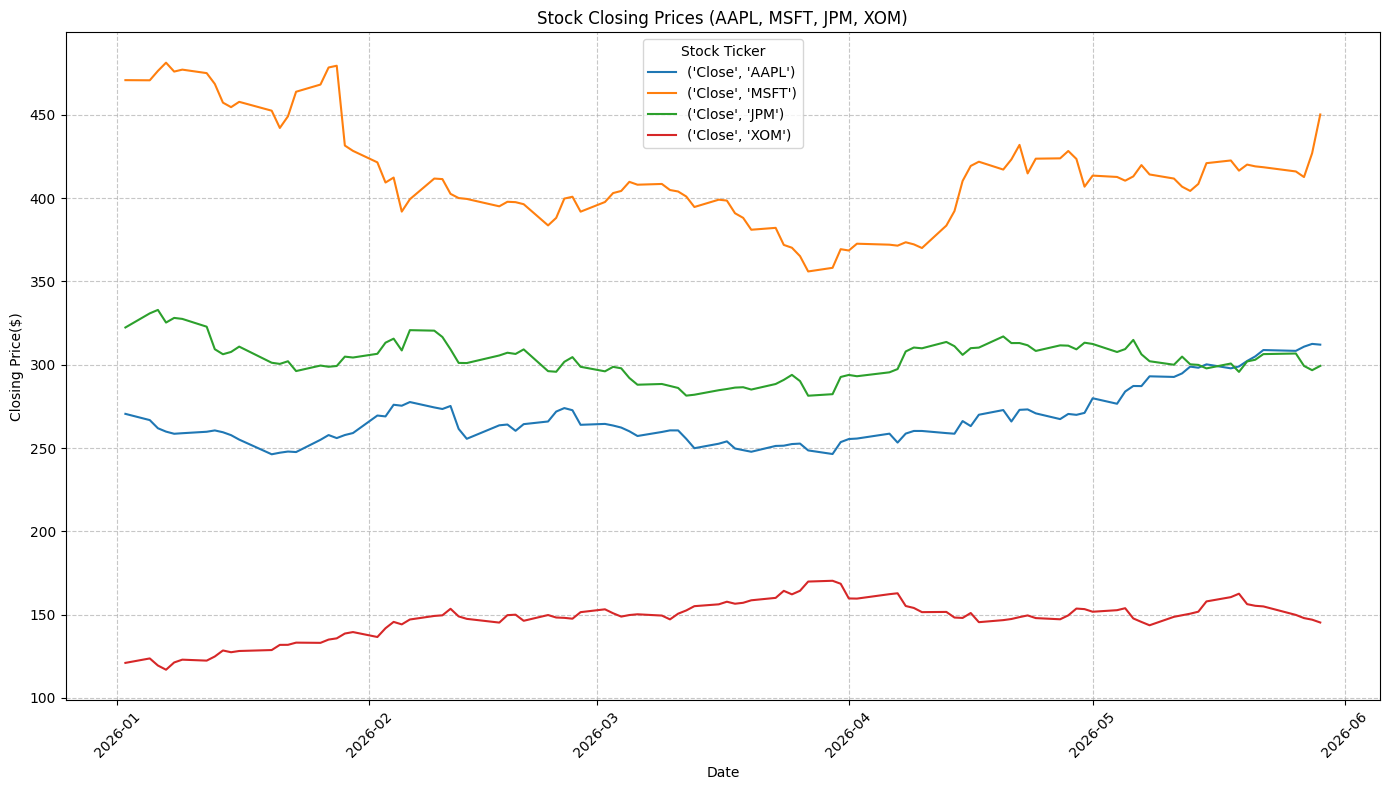

In [ ]:
plt.figure(figsize=(14, 8))
for column in merged_df.columns:
    sns.lineplot(x=merged_df.index, y=merged_df[column], label=column)

plt.title('Stock Closing Prices (AAPL, MSFT, JPM, XOM)')
plt.xlabel('Date')
plt.ylabel('Closing Price($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Stock Ticker')
plt.tight_layout()
plt.show()

/tmp/ipykernel_2361/2303294365.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  full_stock_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


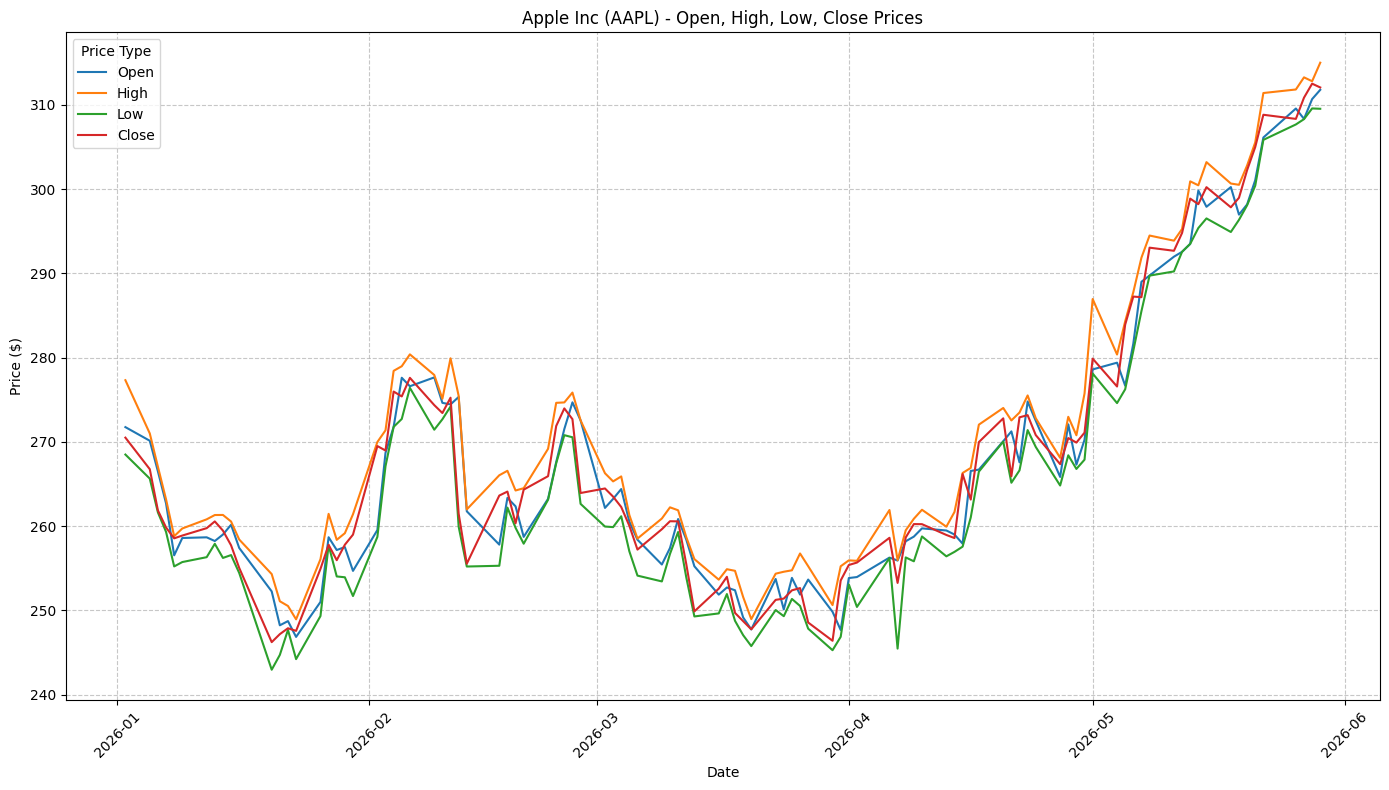

/tmp/ipykernel_2361/2303294365.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  full_stock_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


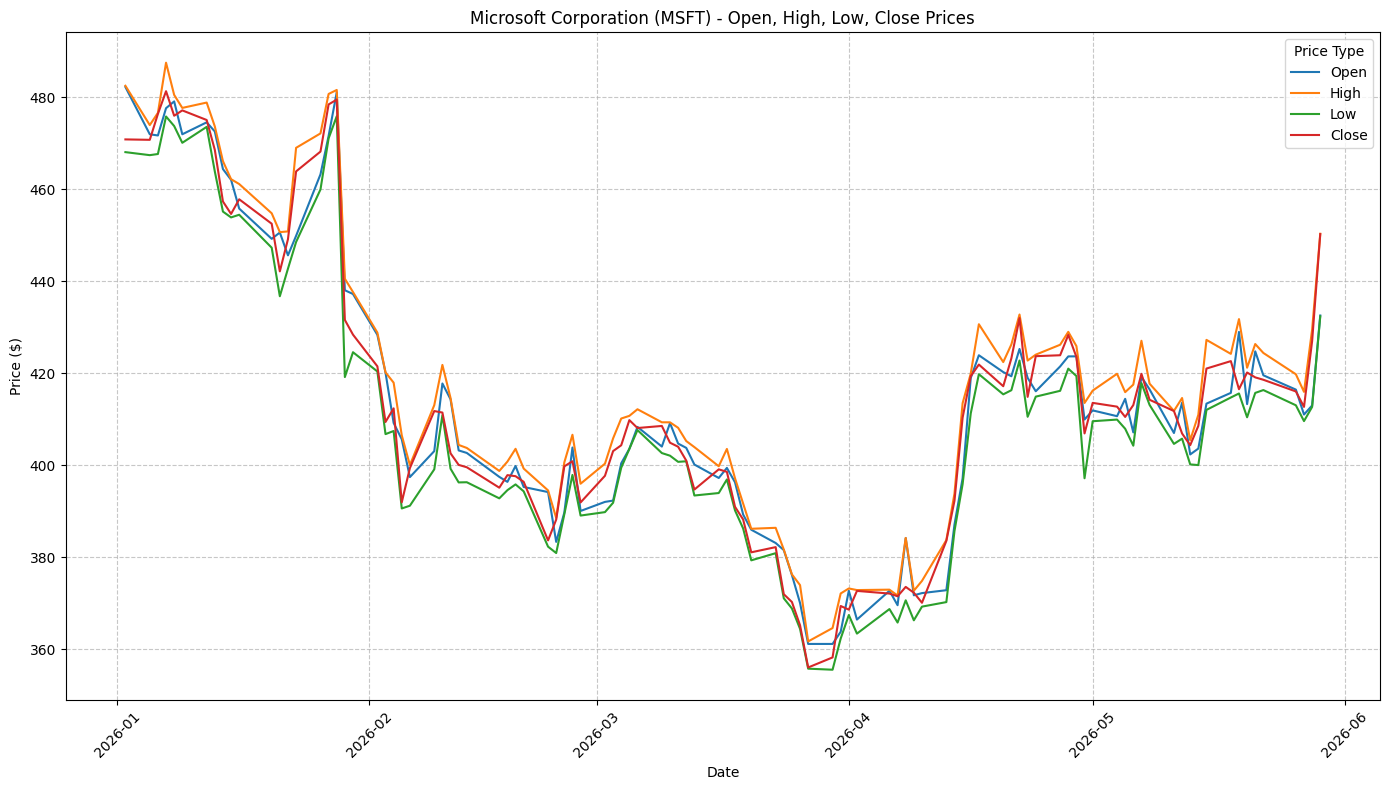

/tmp/ipykernel_2361/2303294365.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  full_stock_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


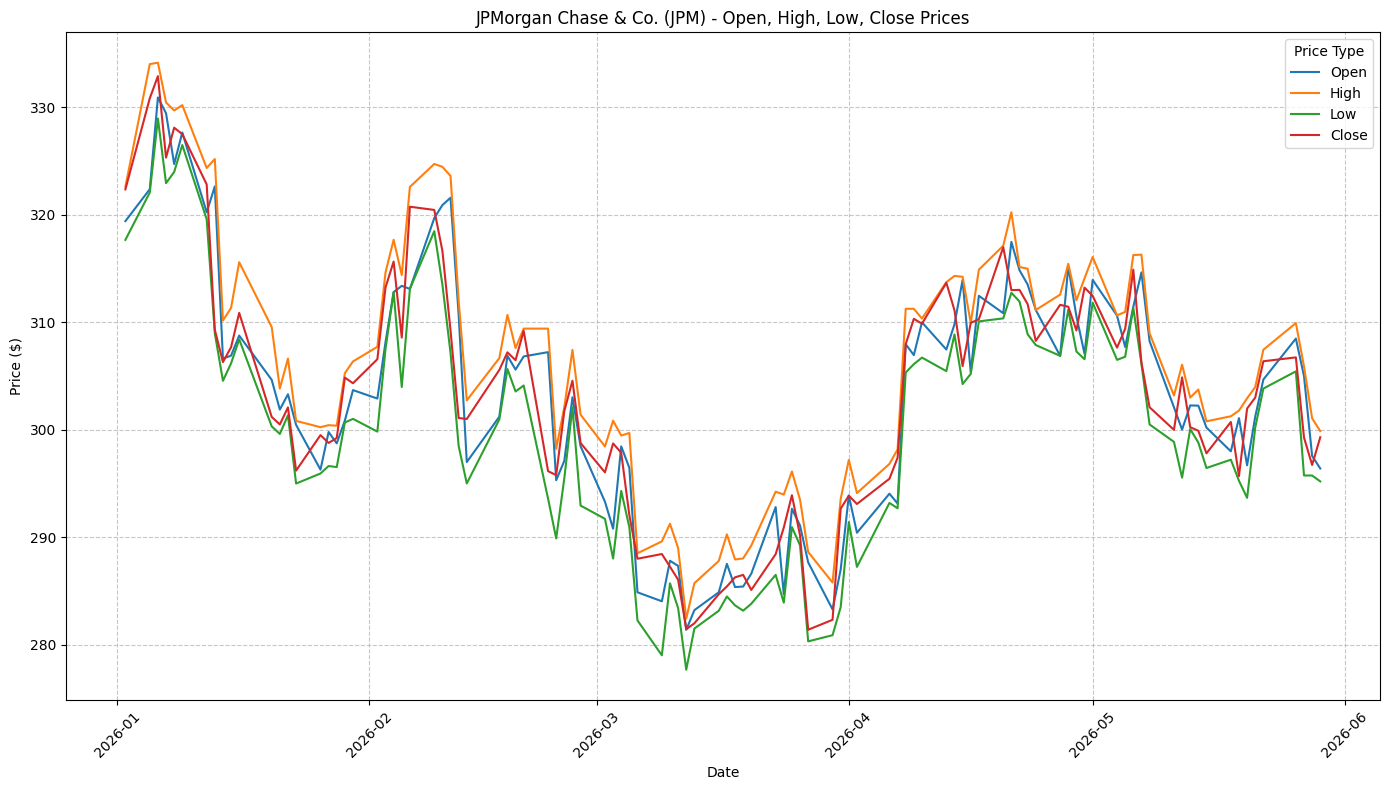

/tmp/ipykernel_2361/2303294365.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  full_stock_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


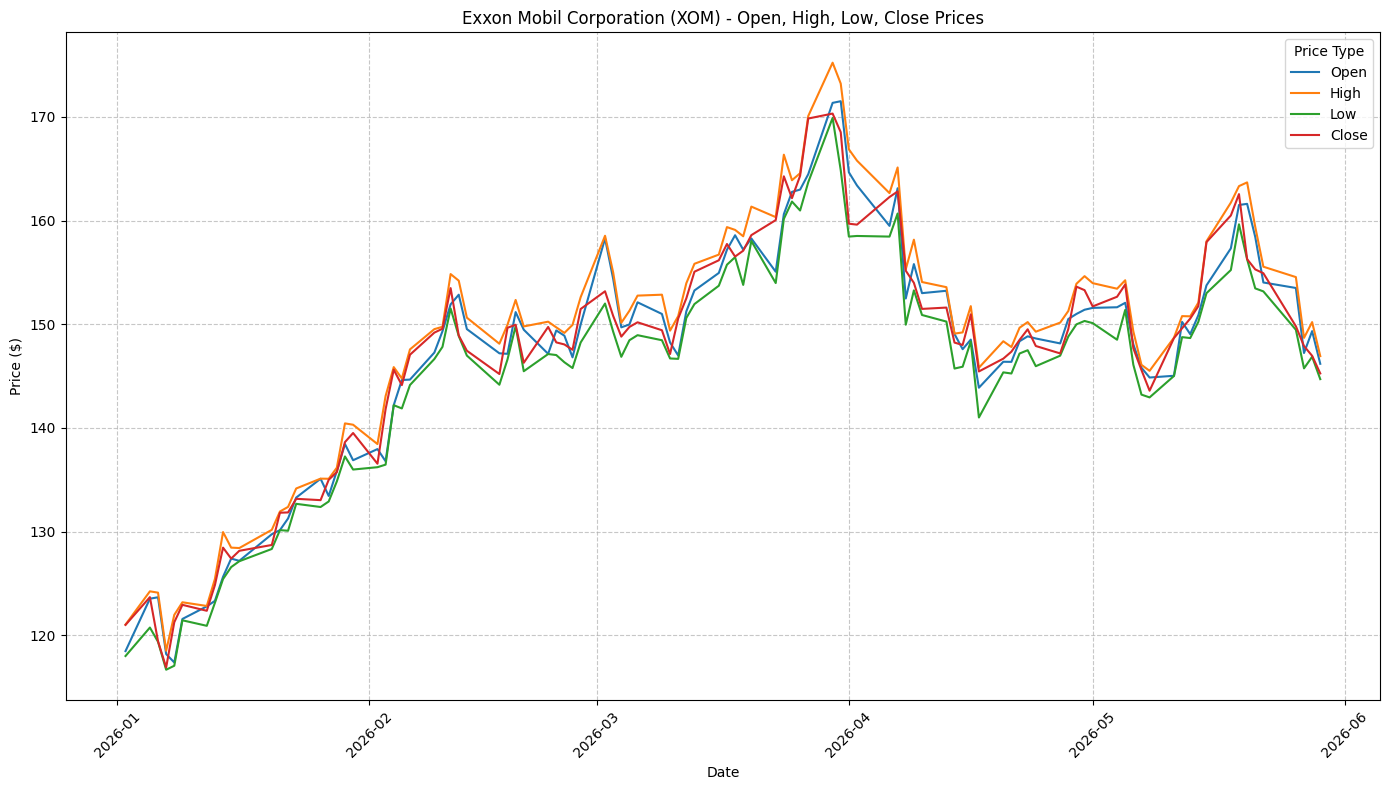

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Define the stocks and the date range
stocks = {
    "AAPL": "Apple Inc",
    "MSFT": "Microsoft Corporation",
    "JPM": "JPMorgan Chase & Co.",
    "XOM": "Exxon Mobil Corporation"
}
start_date = "2026-01-01"
end_date = "2026-05-31"

# Iterate through each stock to download full data and plot
for ticker, name in stocks.items():
    # Download the full stock data
    full_stock_df = yf.download(ticker, start=start_date, end=end_date)

    plt.figure(figsize=(14, 8))
    # Correctly access the multi-indexed columns for each ticker
    sns.lineplot(x=full_stock_df.index, y=full_stock_df[('Open', ticker)], label='Open')
    sns.lineplot(x=full_stock_df.index, y=full_stock_df[('High', ticker)], label='High')
    sns.lineplot(x=full_stock_df.index, y=full_stock_df[('Low', ticker)], label='Low')
    sns.lineplot(x=full_stock_df.index, y=full_stock_df[('Close', ticker)], label='Close')

    plt.title(f'{name} ({ticker}) - Open, High, Low, Close Prices')
    plt.xlabel('Date')
    plt.ylabel('Price ($)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.legend(title='Price Type')
    plt.tight_layout()
    plt.show()

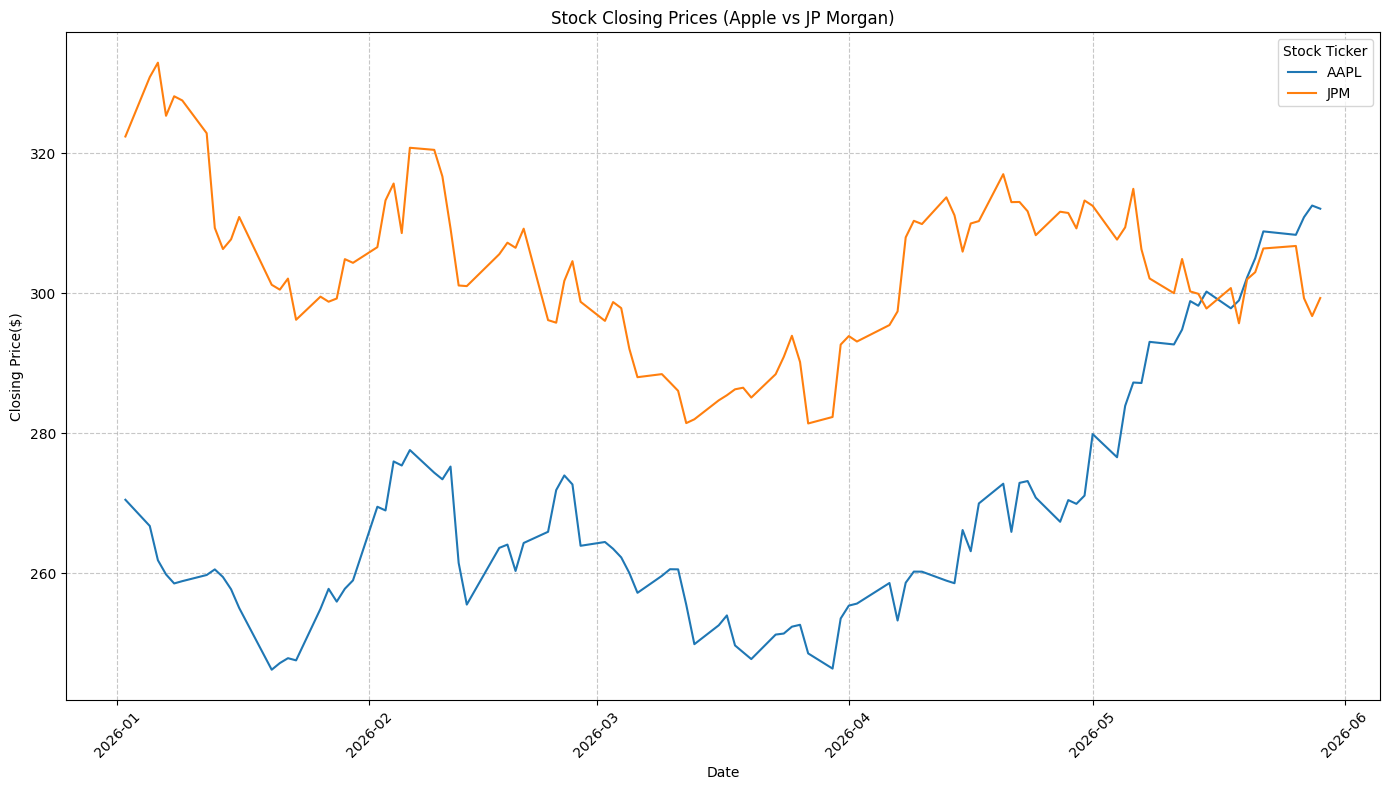

In [ ]:
plt.figure(figsize=(14, 8))
sns.lineplot(x=merged_df.index, y=merged_df[('Close', 'AAPL')], label='AAPL')
sns.lineplot(x=merged_df.index, y=merged_df[('Close', 'JPM')], label='JPM')

plt.title('Stock Closing Prices (Apple vs JP Morgan)')
plt.xlabel('Date')
plt.ylabel('Closing Price($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Stock Ticker')
plt.tight_layout()
plt.show()

In [ ]:
daily_returns_df = merged_df.pct_change() * 100

# Calculate and add 7-day moving average for each stock's daily returns
stocks = ["AAPL", "MSFT", "JPM", "XOM"]
for ticker in stocks:
    col_name = ('Close', ticker)
    ma_col_name = ('Close', f'{ticker}_MA7')
    daily_returns_df[ma_col_name] = daily_returns_df[col_name].rolling(window=7).mean()

In [ ]:
daily_returns_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 102 entries, 2026-01-02 to 2026-05-29
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, AAPL)      101 non-null    float64
 1   (Close, MSFT)      101 non-null    float64
 2   (Close, JPM)       101 non-null    float64
 3   (Close, XOM)       101 non-null    float64
 4   (Close, AAPL_MA7)  95 non-null     float64
 5   (Close, MSFT_MA7)  95 non-null     float64
 6   (Close, JPM_MA7)   95 non-null     float64
 7   (Close, XOM_MA7)   95 non-null     float64
dtypes: float64(8)
memory usage: 7.2 KB


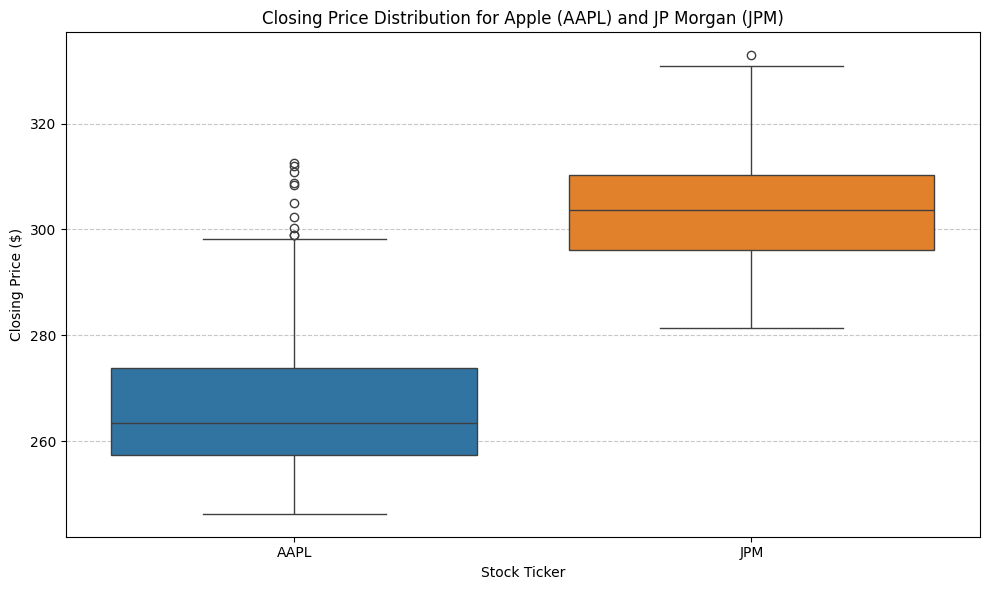

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df[[('Close', 'AAPL'), ('Close', 'JPM')]].droplevel(level=0, axis=1))
plt.title('Closing Price Distribution for Apple (AAPL) and JP Morgan (JPM)')
plt.xlabel('Stock Ticker')
plt.ylabel('Closing Price ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The following are the returns for each stock

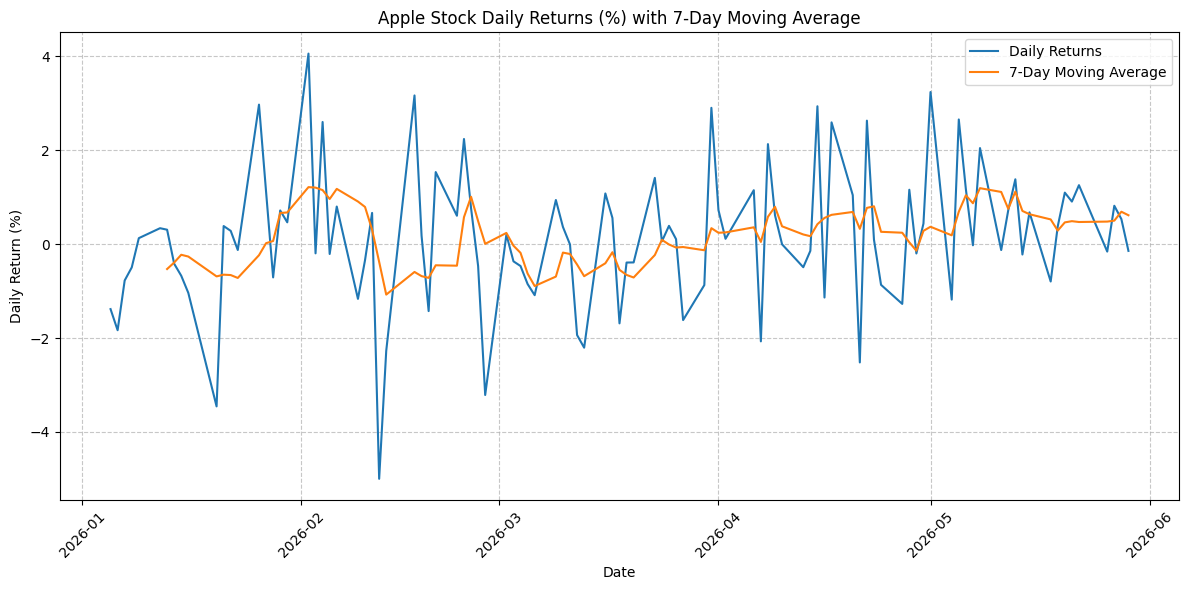

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'AAPL')], label='Daily Returns')

# Calculate and plot 7-day moving average
daily_returns_df[('Close', 'AAPL_MA7')] = daily_returns_df[('Close', 'AAPL')].rolling(window=7).mean()
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'AAPL_MA7')], label='7-Day Moving Average')

plt.title('Apple Stock Daily Returns (%) with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

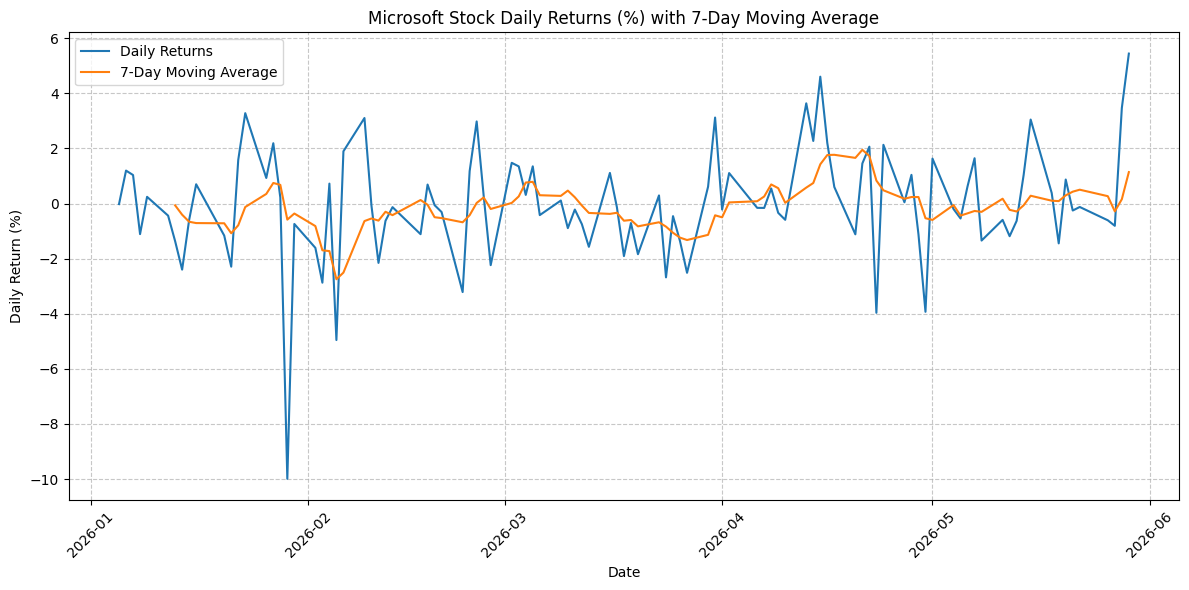

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'MSFT')], label='Daily Returns')

# Calculate and plot 7-day moving average
daily_returns_df[('Close', 'MSFT_MA7')] = daily_returns_df[('Close', 'MSFT')].rolling(window=7).mean()
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'MSFT_MA7')], label='7-Day Moving Average')

plt.title('Microsoft Stock Daily Returns (%) with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

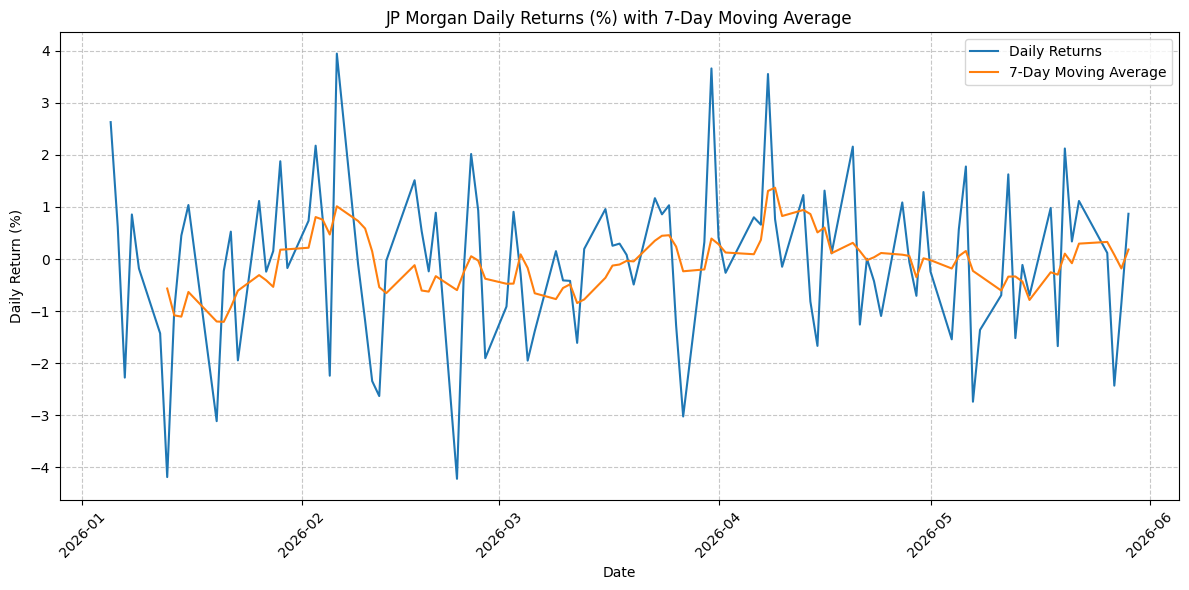

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'JPM')], label='Daily Returns')

# Calculate and plot 7-day moving average
daily_returns_df[('Close', 'MSFT_MA7')] = daily_returns_df[('Close', 'JPM')].rolling(window=7).mean()
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'JPM_MA7')], label='7-Day Moving Average')

plt.title('JP Morgan Daily Returns (%) with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

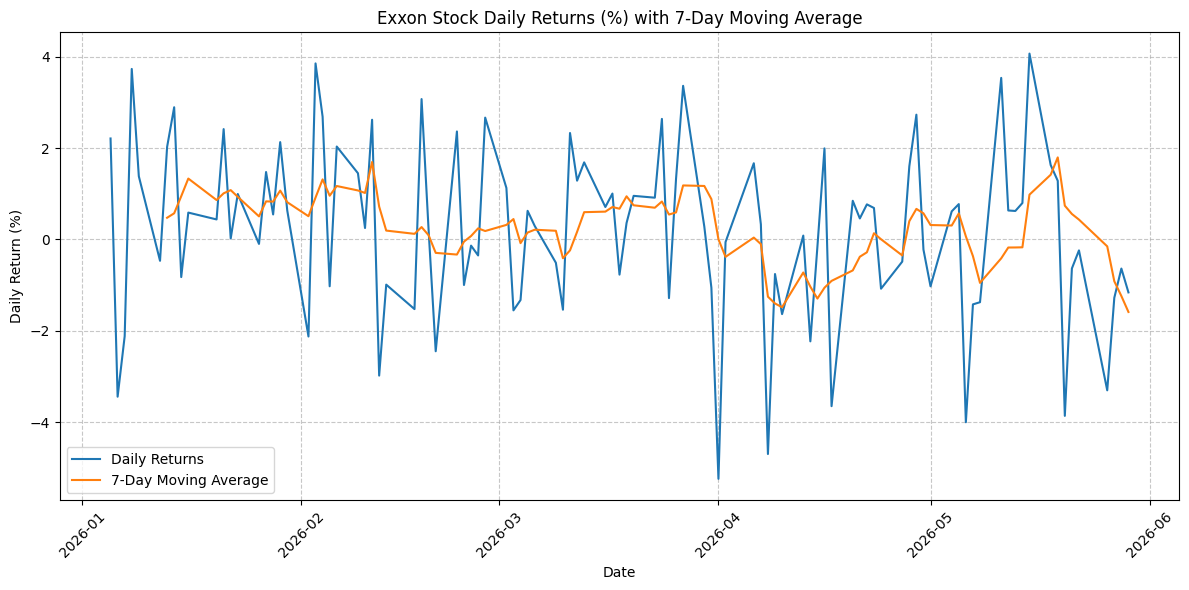

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'XOM')], label='Daily Returns')

# Calculate and plot 7-day moving average
daily_returns_df[('Close', 'XOM_MA7')] = daily_returns_df[('Close', 'XOM')].rolling(window=7).mean()
sns.lineplot(x=daily_returns_df.index, y=daily_returns_df[('Close', 'XOM_MA7')], label='7-Day Moving Average')

plt.title('Exxon Stock Daily Returns (%) with 7-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Distributions

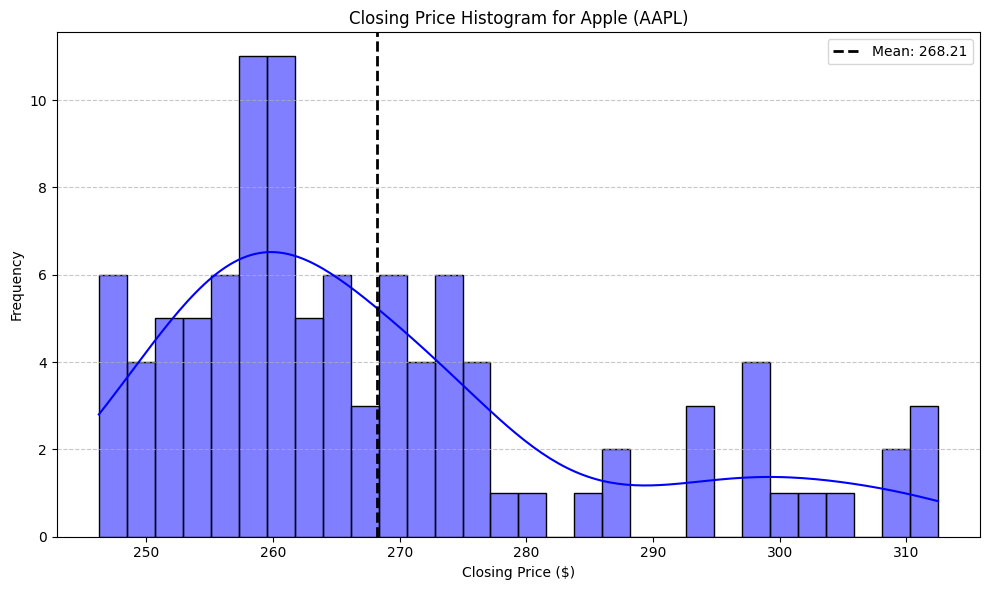

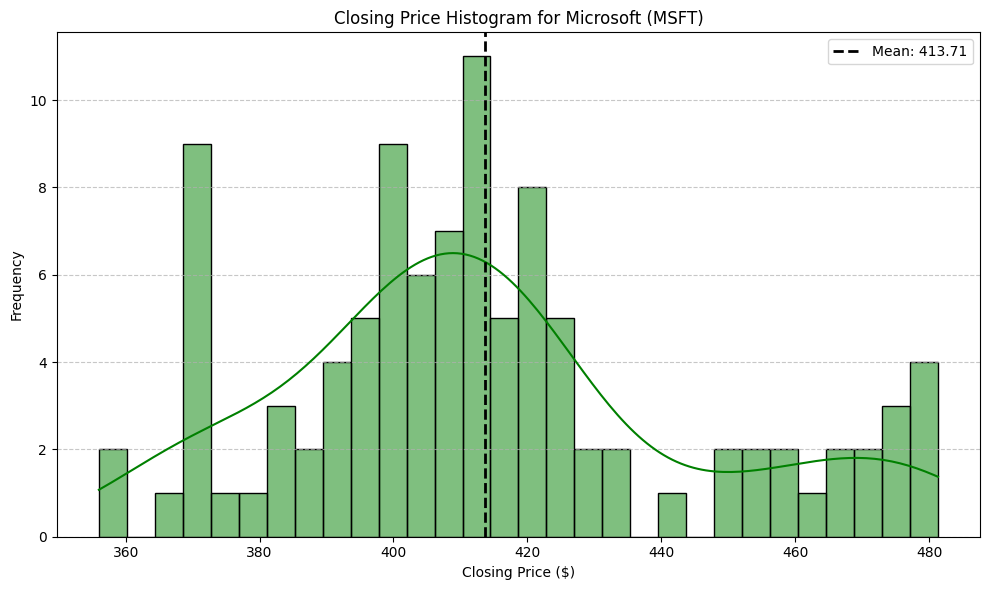

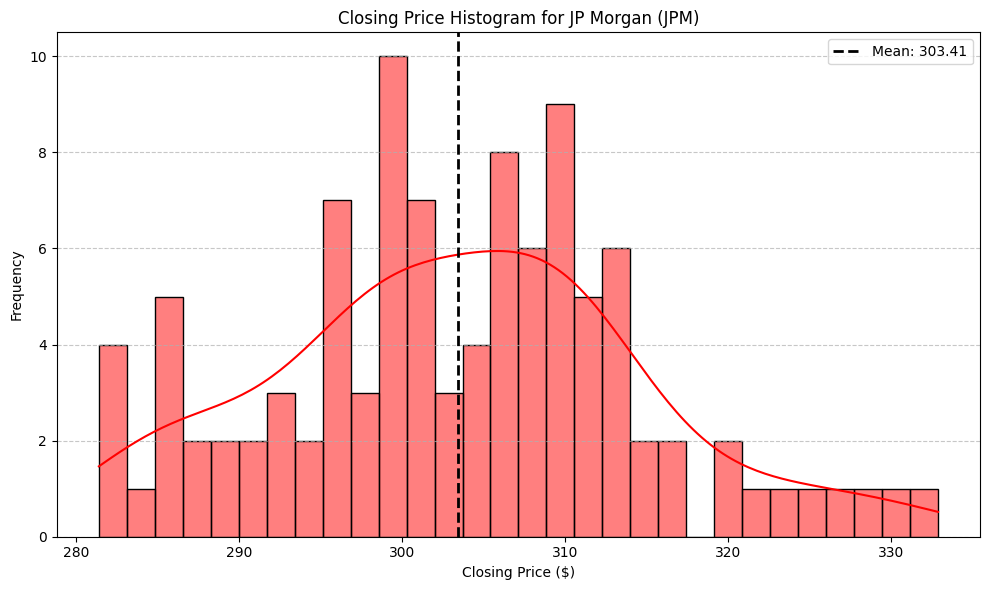

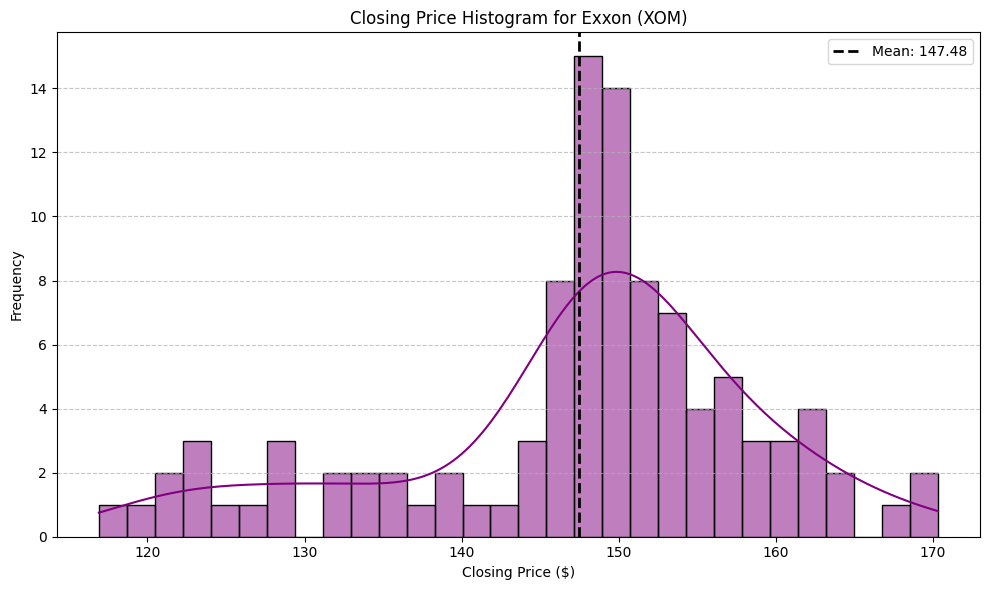

In [ ]:
stock_names = {'AAPL': 'Apple', 'MSFT': 'Microsoft', 'JPM': 'JP Morgan', 'XOM': 'Exxon'}
colors = {'AAPL': 'blue', 'MSFT': 'green', 'JPM': 'red', 'XOM': 'purple'}

for ticker in ['AAPL', 'MSFT', 'JPM', 'XOM']:
    col_name = ('Close', ticker)
    plt.figure(figsize=(10, 6))
    # Use merged_df for closing prices instead of daily_returns_df
    sns.histplot(merged_df[col_name], kde=True, bins=30, color=colors[ticker])

    # Calculate mean for closing prices
    mean_price = merged_df[col_name].mean()
    plt.axvline(mean_price, color='black', linestyle='dashed', linewidth=2, label=f'Mean: {mean_price:.2f}')

    plt.title(f'Closing Price Histogram for {stock_names[ticker]} ({ticker})')
    plt.xlabel('Closing Price ($)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

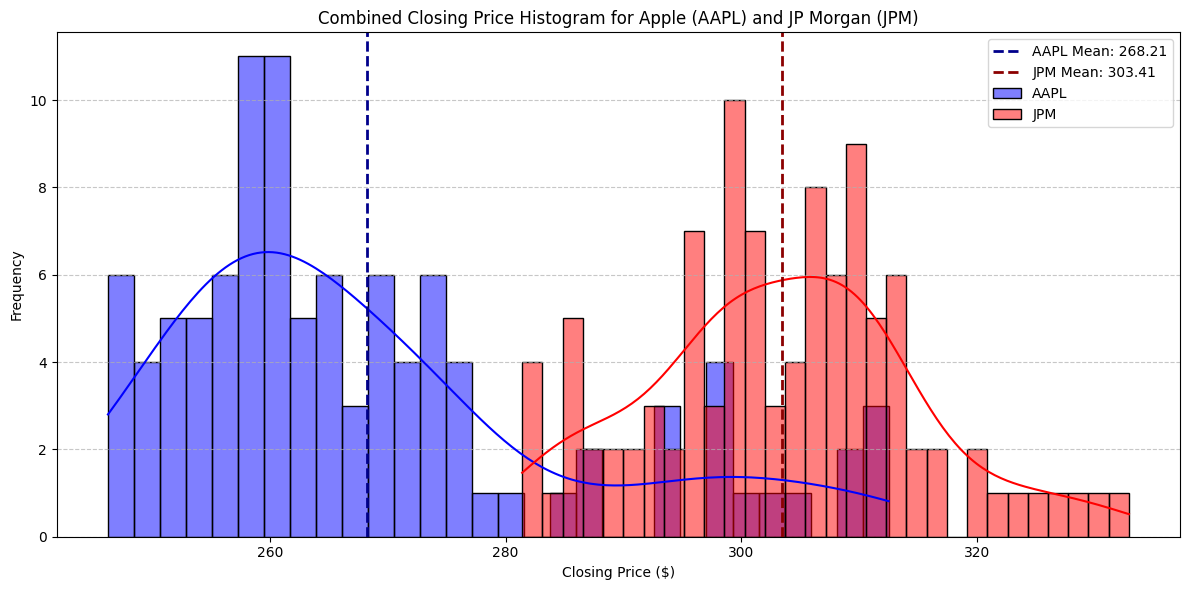

In [ ]:
plt.figure(figsize=(12, 6))

# Apple (AAPL) Closing Prices
aapl_close_col = ('Close', 'AAPL')
mean_aapl_close = merged_df[aapl_close_col].mean()
sns.histplot(merged_df[aapl_close_col], kde=True, bins=30, color='blue', label='AAPL', alpha=0.5)
plt.axvline(mean_aapl_close, color='darkblue', linestyle='dashed', linewidth=2, label=f'AAPL Mean: {mean_aapl_close:.2f}')

# JP Morgan (JPM) Closing Prices
jpm_close_col = ('Close', 'JPM')
mean_jpm_close = merged_df[jpm_close_col].mean()
sns.histplot(merged_df[jpm_close_col], kde=True, bins=30, color='red', label='JPM', alpha=0.5)
plt.axvline(mean_jpm_close, color='darkred', linestyle='dashed', linewidth=2, label=f'JPM Mean: {mean_jpm_close:.2f}')

plt.title('Combined Closing Price Histogram for Apple (AAPL) and JP Morgan (JPM)')
plt.xlabel('Closing Price ($)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

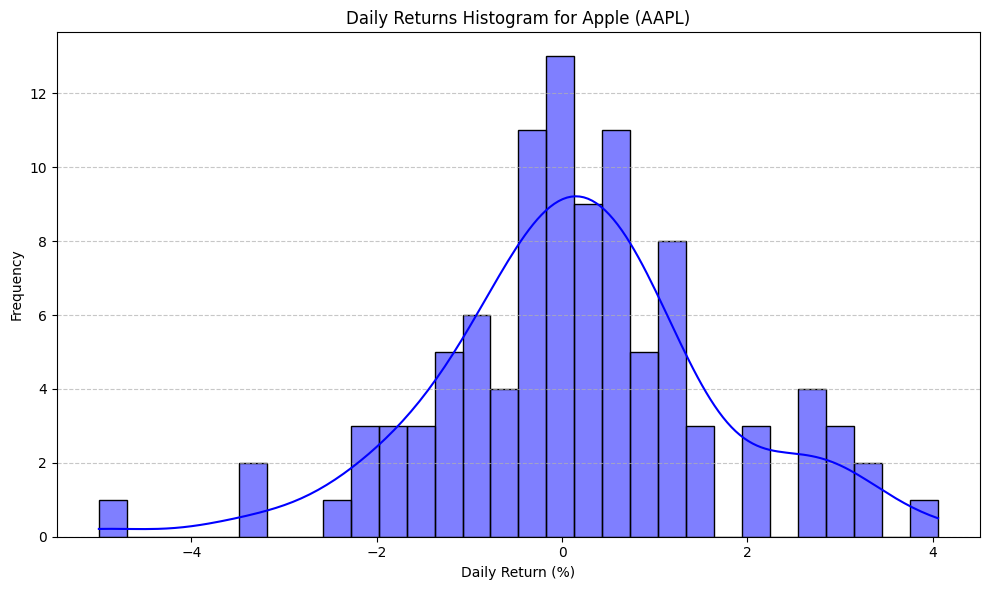

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(daily_returns_df[('Close', 'AAPL')], kde=True, bins=30, color='blue')
plt.title('Daily Returns Histogram for Apple (AAPL)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

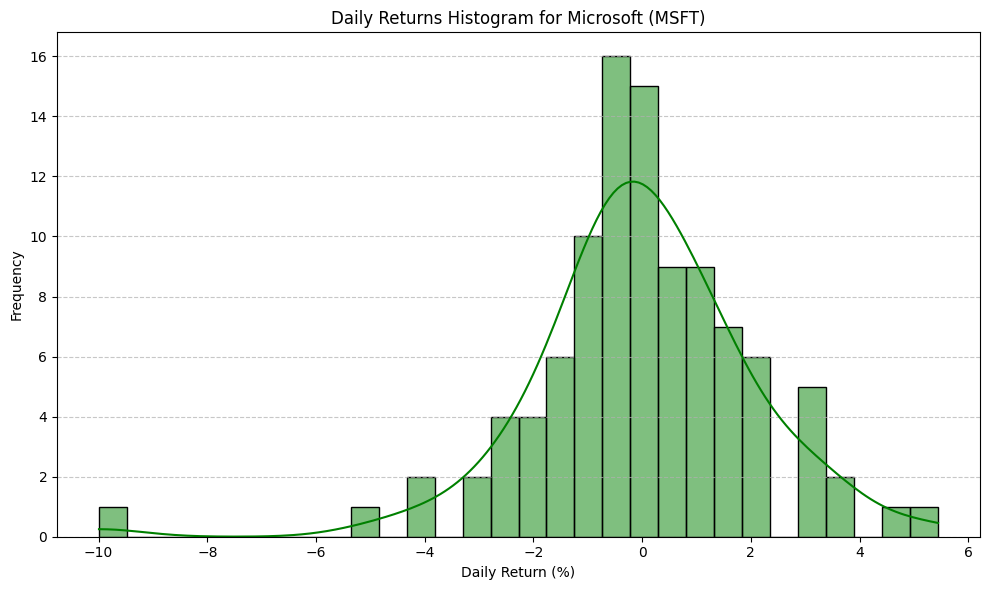

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(daily_returns_df[('Close', 'MSFT')], kde=True, bins=30, color='green')
plt.title('Daily Returns Histogram for Microsoft (MSFT)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

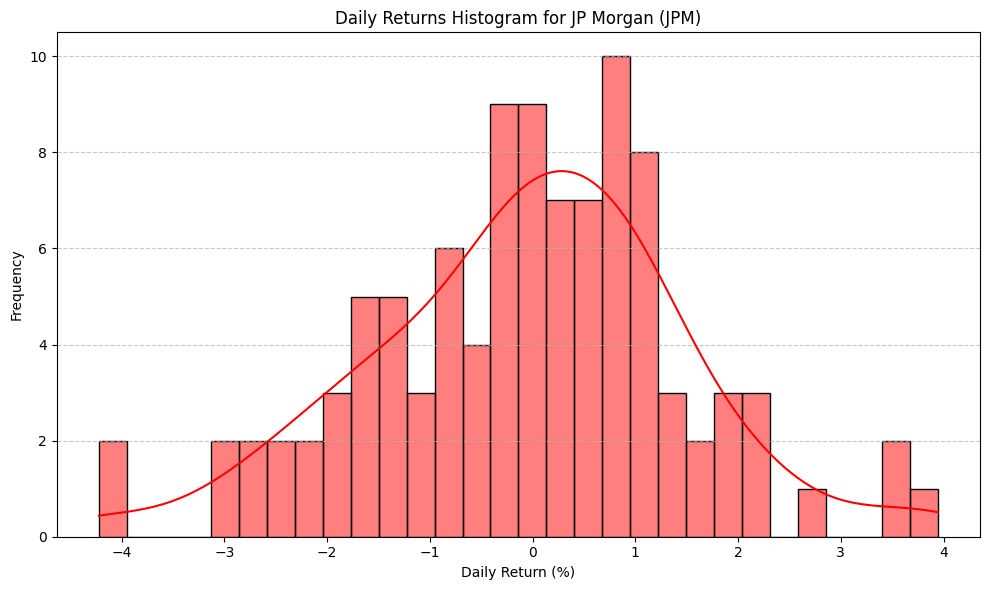

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(daily_returns_df[('Close', 'JPM')], kde=True, bins=30, color='red')
plt.title('Daily Returns Histogram for JP Morgan (JPM)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



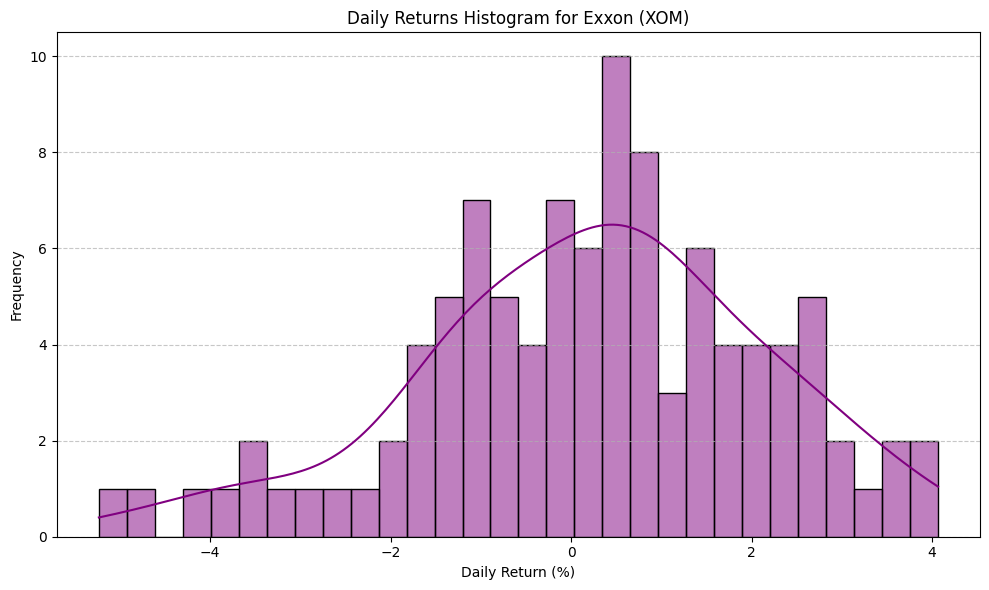

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(daily_returns_df[('Close', 'XOM')], kde=True, bins=30, color='purple')
plt.title('Daily Returns Histogram for Exxon (XOM)')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()